In [201]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

import joblib

In [203]:
#Load the DataSet

In [204]:
df=pd.read_csv("house_dataset.csv")

In [205]:
df.head()

,House_ID,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Location,Furnished,Price
0,1,1002,2,2,2,25,0,Solapur,Unfurnished,86.37
1,2,1013,3,2,1,26,1,Aurangabad,Unfurnished,112.50
2,3,585,2,2,2,4,1,Beed,Unfurnished,69.91
3,4,1676,3,3,2,7,0,Aurangabad,Furnished,150.27
4,5,629,1,1,1,17,3,Pune,Unfurnished,137.27


In [206]:
df.shape

(1000, 10)

In [207]:
#Cleaning data

In [208]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 10


In [209]:
print("Columns Nmae :",df.columns)

Columns Nmae : Index(['House_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Parking',
       'Location', 'Furnished', 'Price'],
      dtype='object')


In [210]:
print("Data Information")
df.info()

Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   House_ID   1000 non-null   int64  
 1   Area       1000 non-null   int64  
 2   Bedrooms   1000 non-null   int64  
 3   Bathrooms  1000 non-null   int64  
 4   Floors     1000 non-null   int64  
 5   Age        1000 non-null   int64  
 6   Parking    1000 non-null   int64  
 7   Location   1000 non-null   object 
 8   Furnished  1000 non-null   object 
 9   Price      1000 non-null   float64
dtypes: float64(1), int64(7), object(2)
memory usage: 78.3+ KB


In [211]:
#Statistical Information
df.describe()

,House_ID,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,500.500000,1260.648000,2.324000,1.823000,1.95700,14.73000,0.995000,132.140940
std,288.819436,434.214088,0.926219,0.870879,0.87973,8.87772,0.909837,47.537709
min,1.000000,450.000000,1.000000,1.000000,1.00000,0.00000,0.000000,38.680000
25%,250.750000,953.000000,2.000000,1.000000,1.00000,7.00000,0.000000,99.850000
50%,500.500000,1265.500000,2.000000,2.000000,2.00000,14.00000,1.000000,124.940000
75%,750.250000,1565.500000,3.000000,2.000000,3.00000,22.00000,2.000000,152.175000
max,1000.000000,2591.000000,5.000000,5.000000,4.00000,30.00000,3.000000,311.490000


In [212]:
#Missing values
df.isnull().sum()

House_ID     0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
Age          0
Parking      0
Location     0
Furnished    0
Price        0
dtype: int64

In [213]:
#duplicated values
df.duplicated().sum()

np.int64(0)

In [214]:
#Remove Duplicated
df = df.drop_duplicates()
print("Duplicates removed.")

print("New Shape:", df.shape)

Duplicates removed.
New Shape: (1000, 10)


In [215]:
print(df["Location"].value_counts())

Location
Amravati      81
Beed          78
Pune          75
Solapur       70
Kolhapur      70
Aurangabad    69
Nanded        66
Ahmednagar    66
Sangli        64
Mumbai        64
Latur         63
Satara        62
Nashik        61
Jalgaon       60
Nagpur        51
Name: count, dtype: int64


In [216]:
# Price Check

In [217]:
print("Minimum Price:", df["Price"].min(), "Lakhs")

Minimum Price: 38.68 Lakhs


In [218]:
print("Maximum Price:", df["Price"].max(), "Lakhs")

Maximum Price: 311.49 Lakhs


In [219]:
print("Average Price:", round(df["Price"].mean(), 2), "Lakhs")

Average Price: 132.14 Lakhs


In [220]:
df.head(10)

,House_ID,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Location,Furnished,Price
0,1,1002,2,2,2,25,0,Solapur,Unfurnished,86.37
1,2,1013,3,2,1,26,1,Aurangabad,Unfurnished,112.50
2,3,585,2,2,2,4,1,Beed,Unfurnished,69.91
3,4,1676,3,3,2,7,0,Aurangabad,Furnished,150.27
4,5,629,1,1,1,17,3,Pune,Unfurnished,137.27
5,6,537,2,2,2,12,0,Pune,Furnished,160.88
6,7,546,1,1,1,7,2,Sangli,Semi-Furnished,70.28
7,8,1744,3,3,2,26,1,Solapur,Furnished,144.75
8,9,1233,3,2,2,9,1,Solapur,Furnished,121.10
9,10,1440,3,2,1,26,3,Solapur,Unfurnished,114.13


In [221]:
#Exploratory Data Analysis

In [222]:
#Location-wise Average House Price
location_price = df.groupby("Location")["Price"].mean().sort_values(ascending=False)

print("Average House Price by Location:")
print(location_price.round(2))

Average House Price by Location:
Location
Mumbai        253.51
Pune          185.37
Nashik        145.55
Nagpur        135.51
Kolhapur      123.15
Aurangabad    122.03
Solapur       121.09
Ahmednagar    120.72
Sangli        120.50
Jalgaon       118.71
Satara        116.14
Latur         111.93
Amravati      109.48
Nanded        104.94
Beed          100.75
Name: Price, dtype: float64


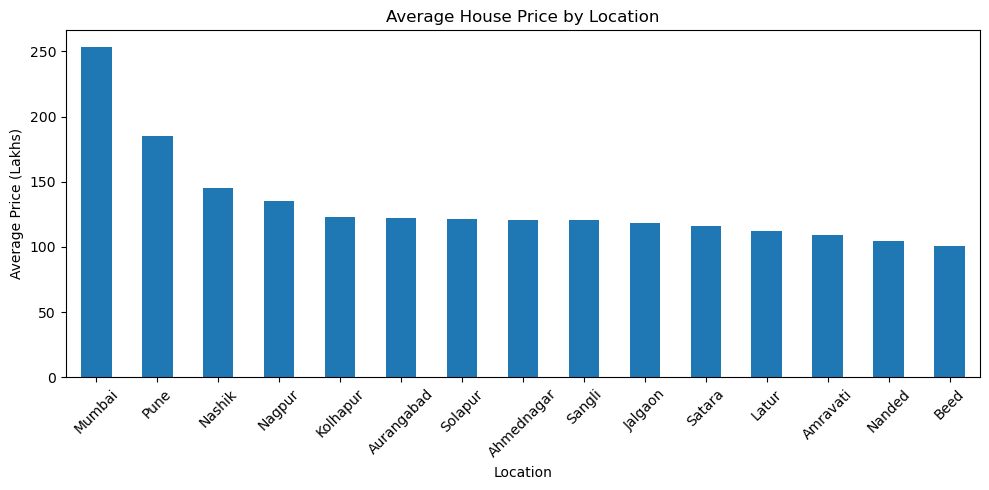

In [223]:
#Location vs Average Price
plt.figure(figsize=(10, 5))

location_price.plot(kind="bar")

plt.title("Average House Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

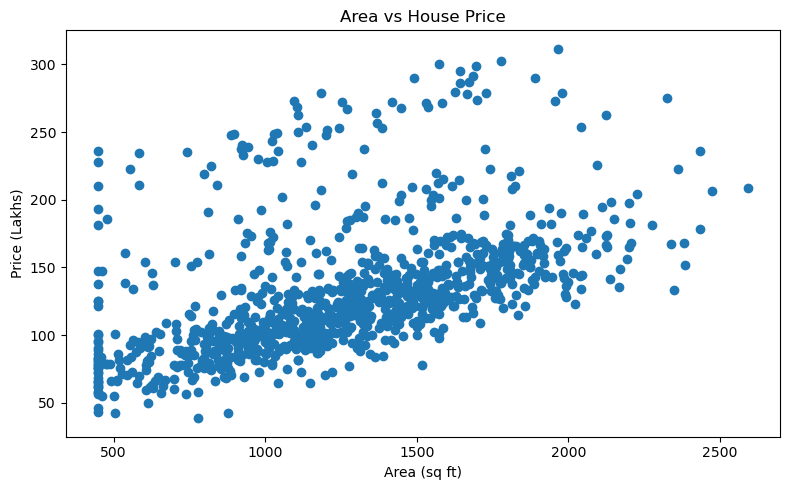

In [ ]:
#Area vs Price
plt.figure(figsize=(8, 5))

plt.scatter(df["Area"], df["Price"])

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakhs)")

plt.tight_layout()
plt.show()

In [225]:
#Bedrooms vs Average Price
bedroom_price = df.groupby("Bedrooms")["Price"].mean()

print("Average Price by Number of Bedrooms:")
print(bedroom_price.round(2))

Average Price by Number of Bedrooms:
Bedrooms
1    101.49
2    125.10
3    147.73
4    171.55
5    168.64
Name: Price, dtype: float64


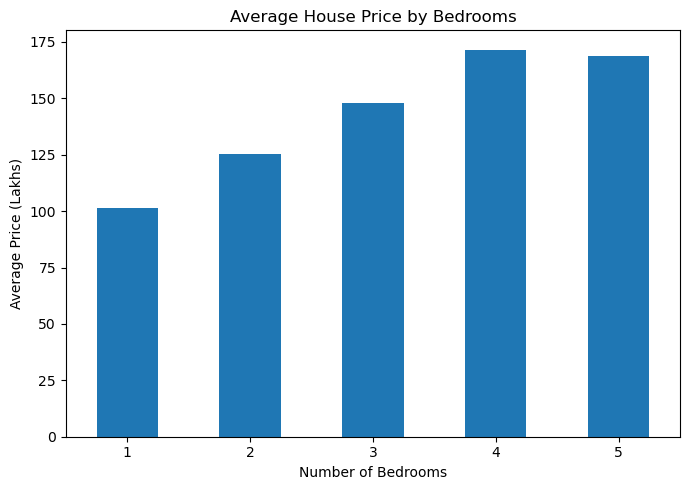

In [226]:
plt.figure(figsize=(7, 5))

bedroom_price.plot(kind="bar")

plt.title("Average House Price by Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [227]:
#Bathrooms vs Average Price
bathroom_price = df.groupby("Bathrooms")["Price"].mean()

print("Average Price by Number of Bathrooms:")
print(bathroom_price.round(2))

Average Price by Number of Bathrooms:
Bathrooms
1    113.20
2    139.34
3    156.07
4    171.73
5    166.85
Name: Price, dtype: float64


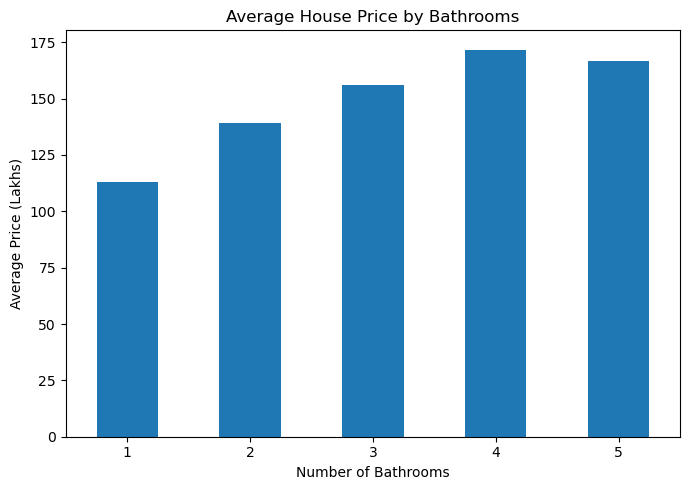

In [228]:
plt.figure(figsize=(7, 5))

bathroom_price.plot(kind="bar")

plt.title("Average House Price by Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [229]:
#Furnished vs Price

furnished_price = df.groupby("Furnished")["Price"].mean()

print("Average Price by Furnishing Type:")
print(furnished_price.round(2))

Average Price by Furnishing Type:
Furnished
Furnished         138.53
Semi-Furnished    132.68
Unfurnished       126.64
Name: Price, dtype: float64


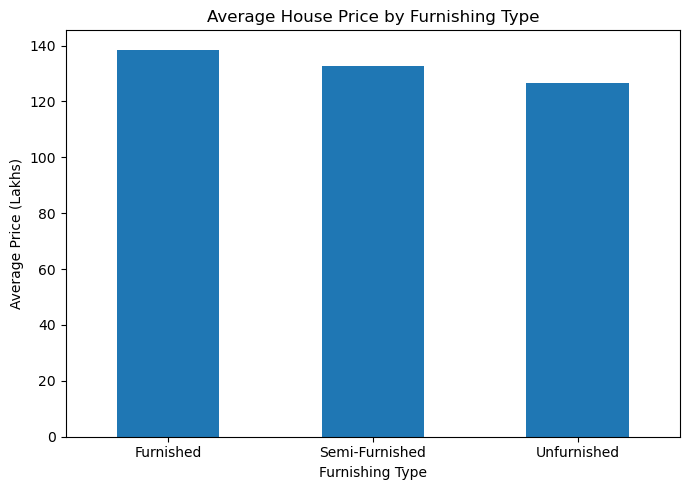

In [230]:
plt.figure(figsize=(7, 5))

furnished_price.plot(kind="bar")

plt.title("Average House Price by Furnishing Type")
plt.xlabel("Furnishing Type")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [231]:
#Parking vs Price
parking_price = df.groupby("Parking")["Price"].mean()

print("Average Price by Parking Spaces:")
print(parking_price.round(2))

Average Price by Parking Spaces:
Parking
0    126.48
1    133.41
2    135.45
3    143.19
Name: Price, dtype: float64


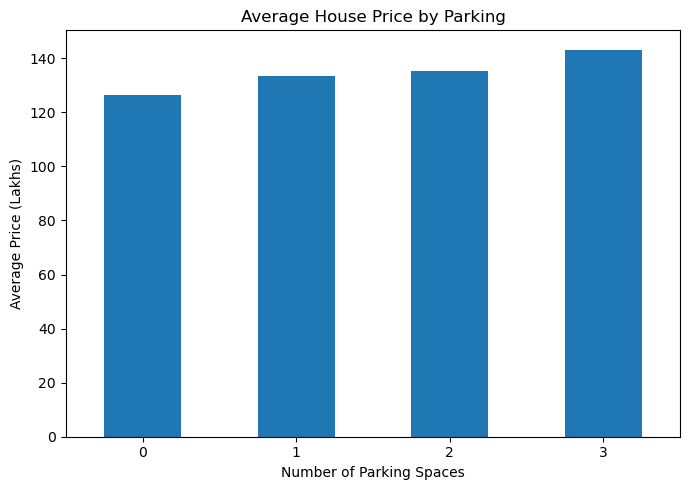

In [232]:
plt.figure(figsize=(7, 5))

parking_price.plot(kind="bar")

plt.title("Average House Price by Parking")
plt.xlabel("Number of Parking Spaces")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [233]:
#Floor VS Price
floor_price = df.groupby("Floors")["Price"].mean()

print("Average Price by Floors:")
print(floor_price.round(2))

Average Price by Floors:
Floors
1    131.34
2    133.78
3    130.70
4    130.60
Name: Price, dtype: float64


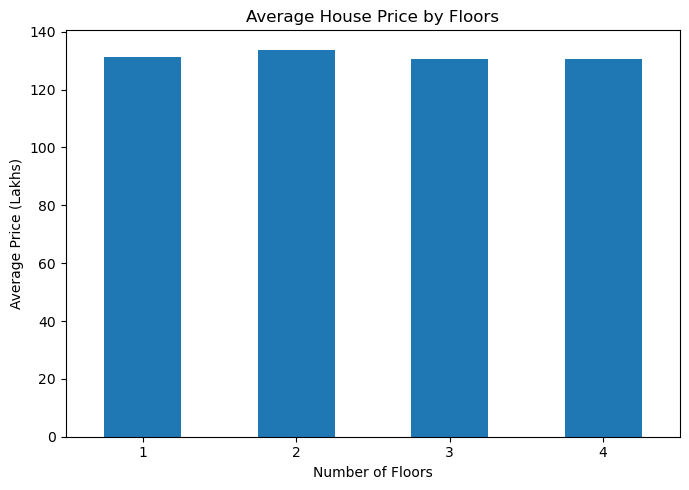

In [234]:
plt.figure(figsize=(7, 5))

floor_price.plot(kind="bar")

plt.title("Average House Price by Floors")
plt.xlabel("Number of Floors")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

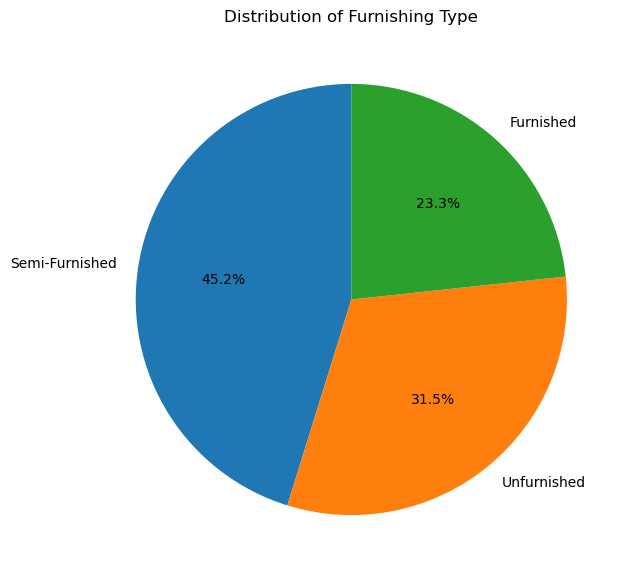

In [235]:
#pie chart
furnished_count = df["Furnished"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    furnished_count,
    labels=furnished_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Furnishing Type")

plt.show()

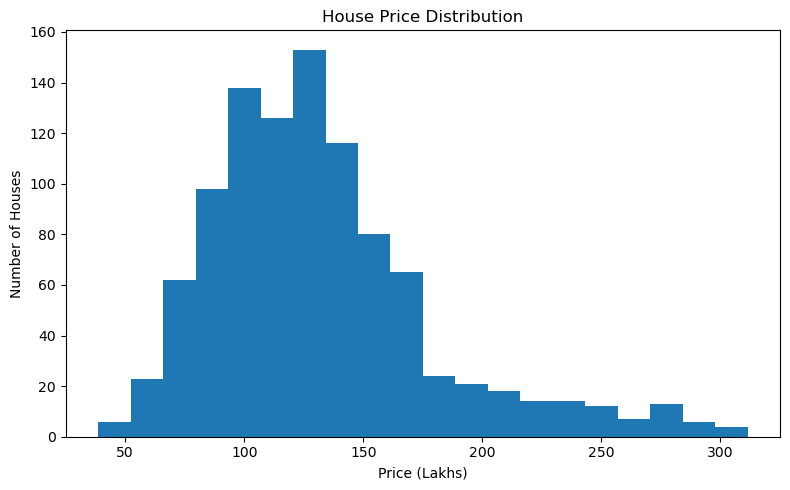

In [236]:
#Price Distribution 
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=20)

plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

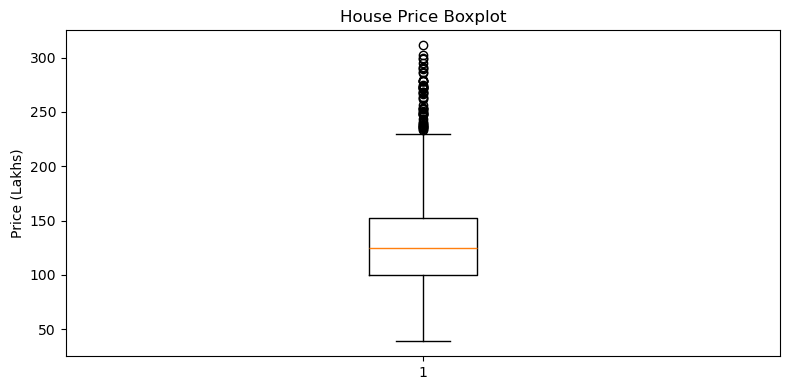

In [237]:
#House Price
plt.figure(figsize=(8, 4))

plt.boxplot(df["Price"])

plt.title("House Price Boxplot")
plt.ylabel("Price (Lakhs)")

plt.tight_layout()
plt.show()

In [238]:
df.corr(numeric_only=True)

,House_ID,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Price
House_ID,1.000000,0.013337,-0.007985,-0.011392,0.036274,0.019355,-0.000989,0.006887
Area,0.013337,1.000000,0.811108,0.675750,-0.008027,-0.029217,0.022128,0.498030
Bedrooms,-0.007985,0.811108,1.000000,0.846777,-0.036938,-0.015159,0.000736,0.439148
Bathrooms,-0.011392,0.675750,0.846777,1.000000,-0.023010,0.002876,0.015305,0.379436
Floors,0.036274,-0.008027,-0.036938,-0.023010,1.000000,-0.023149,-0.002770,-0.004166
Age,0.019355,-0.029217,-0.015159,0.002876,-0.023149,1.000000,-0.054448,-0.141437
Parking,-0.000989,0.022128,0.000736,0.015305,-0.002770,-0.054448,1.000000,0.096965
Price,0.006887,0.498030,0.439148,0.379436,-0.004166,-0.141437,0.096965,1.000000


In [239]:
#Correlation Analysis
numeric_columns = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "Age",
    "Parking",
    "Price"
]

correlation = df[numeric_columns].corr()

print("Correlation with Price:")
print(correlation["Price"].sort_values(ascending=False))

Correlation with Price:
Price        1.000000
Area         0.498030
Bedrooms     0.439148
Bathrooms    0.379436
Parking      0.096965
Floors      -0.004166
Age         -0.141437
Name: Price, dtype: float64


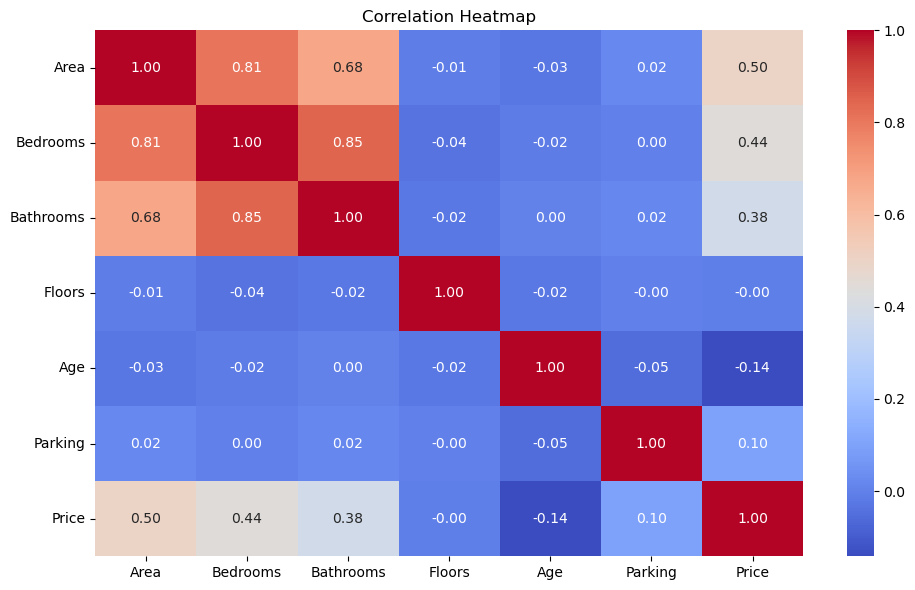

In [240]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

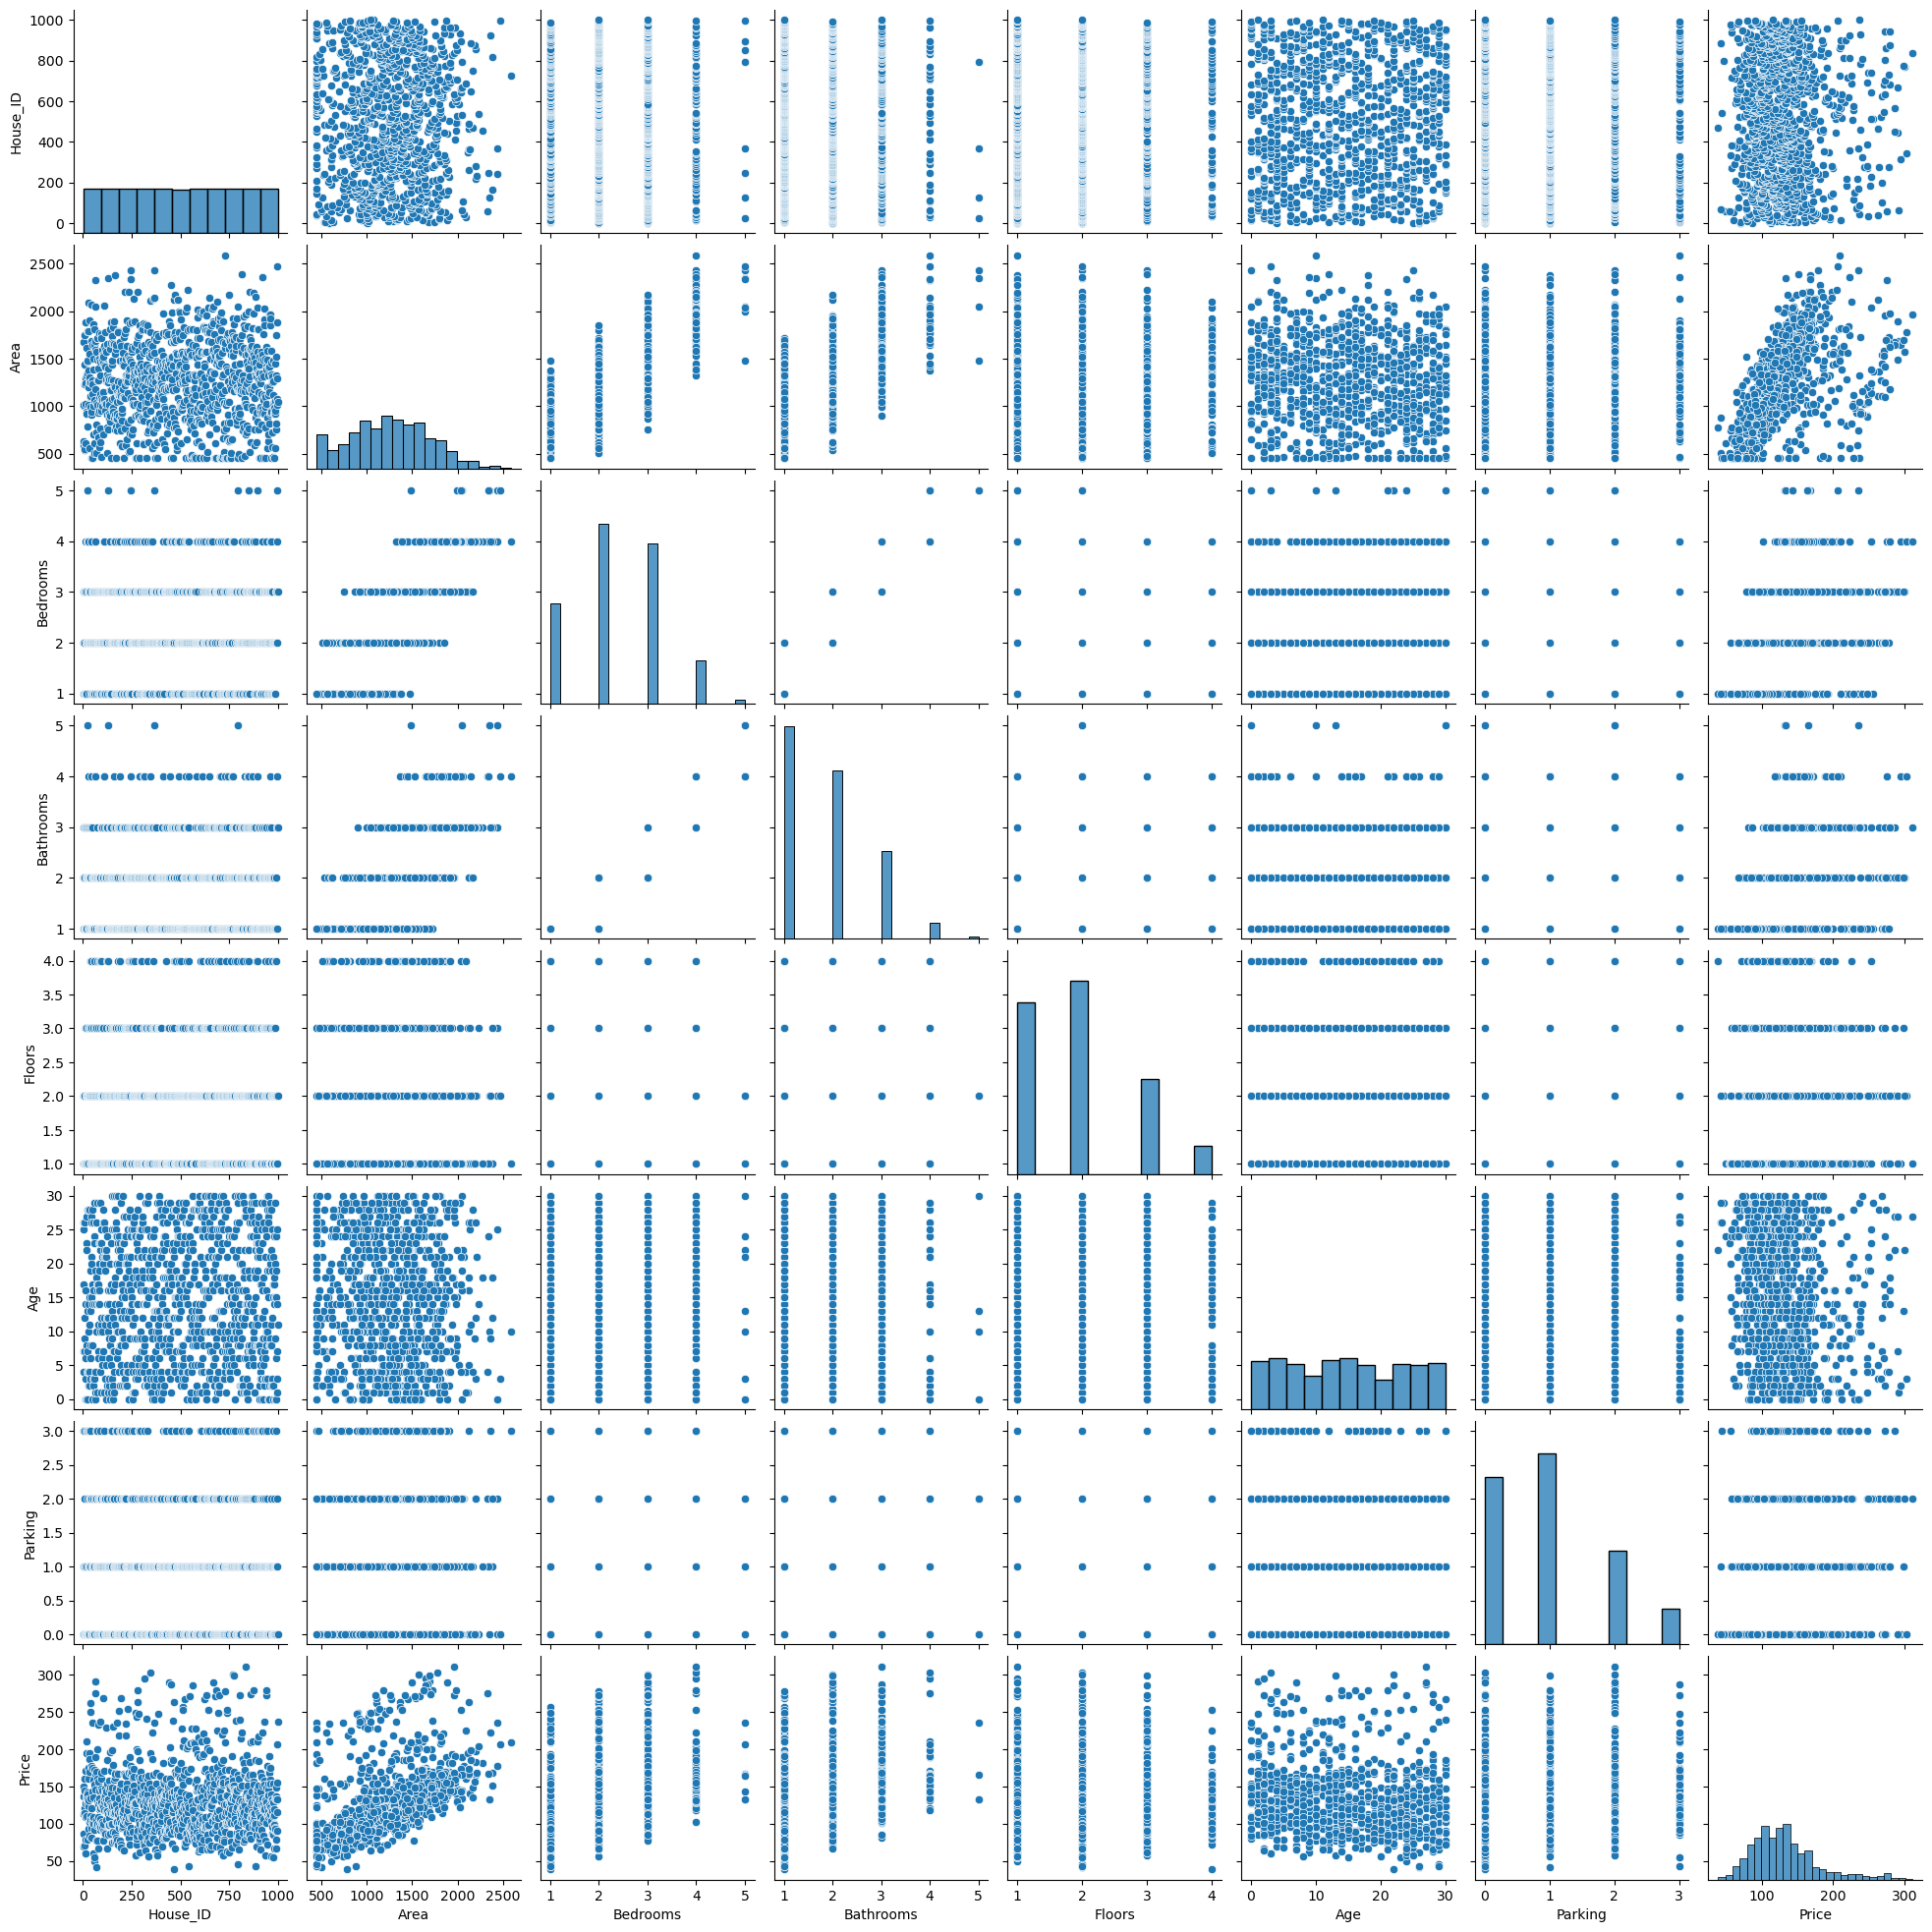

In [241]:
sns.pairplot(df)
plt.show()

In [242]:
#Features and Target Select doing

In [243]:
X = df[
    [
        "Area",
        "Bedrooms",
        "Bathrooms",
        "Floors",
        "Age",
        "Parking",
        "Location",
        "Furnished"
    ]
]

y = df["Price"]

In [244]:
#Input variable
X.head()

,Area,Bedrooms,Bathrooms,Floors,Age,Parking,Location,Furnished
0,1002,2,2,2,25,0,Solapur,Unfurnished
1,1013,3,2,1,26,1,Aurangabad,Unfurnished
2,585,2,2,2,4,1,Beed,Unfurnished
3,1676,3,3,2,7,0,Aurangabad,Furnished
4,629,1,1,1,17,3,Pune,Unfurnished


In [245]:
#target
y.head()

0     86.37
1    112.50
2     69.91
3    150.27
4    137.27
Name: Price, dtype: float64

In [246]:
#Numerical and Categorical Features sepration

In [247]:
numeric_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "Age",
    "Parking"
]

In [248]:
print("numeric_features")
numeric_features

numeric_features


['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'Parking']

In [249]:
categorical_features = [
    "Location",
    "Furnished"
]

In [250]:
print("categorical_features")
categorical_features

categorical_features


['Location', 'Furnished']

In [251]:
#Categorical Data Encoding

In [252]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [253]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [255]:
preprocessor

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [256]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(), categorical_features)
], remainder="passthrough")

In [257]:
preprocessor

,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [258]:
#Train  Test  Split data

In [259]:
from sklearn.model_selection import train_test_split

In [260]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [261]:
#training data 
X_train.shape

(800, 8)

In [262]:
#testing data
X_test.shape

(200, 8)

In [263]:
#cheacking data

In [264]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 8)
X_test: (200, 8)
y_train: (800,)
y_test: (200,)


In [265]:
#MODEL TRAINING

In [266]:
from sklearn.ensemble import RandomForestRegressor

In [267]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [268]:
model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [269]:
#Preprocessing and Model combning

In [270]:
from sklearn.pipeline import Pipeline

In [271]:
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ]
)

In [272]:
pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [273]:
#Train the model

In [274]:
pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [275]:
#predation

In [276]:
y_pred = pipeline.predict(X_test)

In [277]:
print("Predicted Prices:")
print(y_pred[:10])

Predicted Prices:
[168.5448 241.8634  90.8154 113.1874 165.2601 111.4596 130.5608  95.9379
 280.7933 157.1391]


In [278]:
# compareing Actual and Predicted Price 
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

In [279]:
comparison

,Actual Price,Predicted Price
0,172.52,168.5448
1,249.45,241.8634
2,99.93,90.8154
3,124.29,113.1874
4,181.76,165.2601
5,108.68,111.4596
6,101.34,130.5608
7,101.55,95.9379
8,273.67,280.7933
9,148.28,157.1391


In [280]:
#Model Traning

In [281]:
print("Random Forest Model Training Completed!")
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Random Forest Model Training Completed!
Training Records: 800
Testing Records: 200


In [282]:
#Model Evaluation

In [283]:
#Mean
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", round(mae, 2), "Lakhs")

Mean Absolute Error: 9.52 Lakhs


In [284]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", round(rmse, 2), "Lakhs")

Root Mean Squared Error: 12.12 Lakhs


In [285]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", round(r2, 2))

R2 Score: 0.94


In [286]:
print("Model Evaluation")
print("-------------------------")
print("MAE  :", round(mae, 2), "Lakhs")
print("RMSE :", round(rmse, 2), "Lakhs")
print("R2 Score:", round(r2, 2))

Model Evaluation
-------------------------
MAE  : 9.52 Lakhs
RMSE : 12.12 Lakhs
R2 Score: 0.94


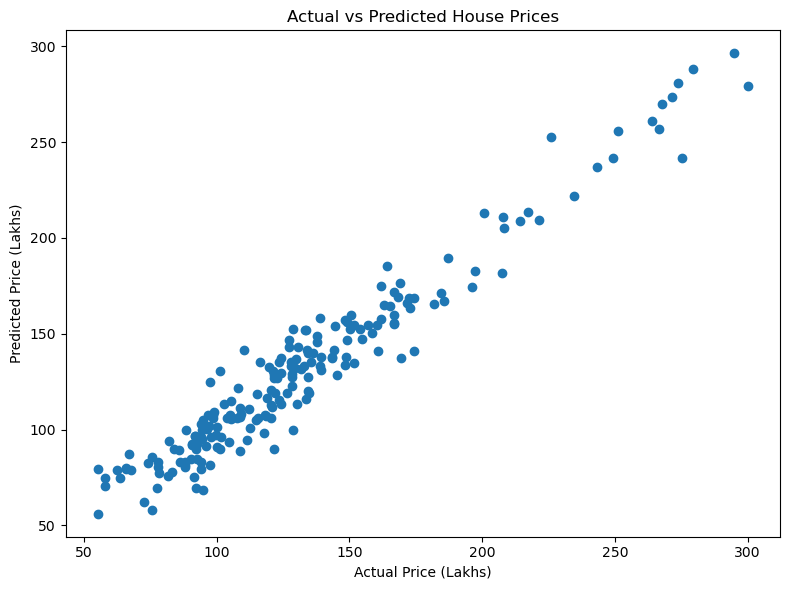

In [287]:
#Actual VS Predicted
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")

plt.title("Actual vs Predicted House Prices")

plt.tight_layout()
plt.show()

In [288]:
#model saving

In [289]:
import joblib

joblib.dump(pipeline, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("house_price_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!
